<center>Universidade Federal de Viçosa</center>
<center>Coordenadoria de Educação Aberta e a Distância</center>
<center>Inteligência Artificial e Computacional</center>
<center>ELT578 - Análise de Imagens e Visão Computacional</center>

**<center>AULA PRÁTICA 4: Transformações Geométricas e Morfologicas, e Métricas de Qualidade de Imagem </center>**

*   **Transformações Geométricas:** translação, rotação, escalonamento, cisalhamento, reflexão e distorção (perspectiva).

*   **Transformações Morfológicas:** operações baseadas na forma (atuam principalmente sobre estruturas binárias).

*   **Métricas de Qualidade de Imagem:** construção de pequenas imagens e análise visual.


**1) Montando o Google Drive**

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**2) Importando bibliotecas**

In [15]:
import numpy as np
import cv2
from google.colab.patches import cv2_imshow

**3) Transformações Geométricas**

* Translação: Move a imagem em uma direção específica, adicionando ou subtraindo uma quantidade fixa de pixels a todas as coordenadas dos pontos da imagem.
* Rotação: Gira a imagem em torno de um ponto específico, geralmente o centro da imagem, por um determinado ângulo.
* Escalonamento: Aumenta ou diminui o tamanho da imagem, alterando as distâncias entre os pontos dos eixos x e y por um fator de escala.
* Cisalhamento (Shear): Deforma a imagem alongando ou inclinando-a ao longo de um eixo, geralmente o eixo x ou y.
* Reflexão (Flip): Inverte a imagem horizontal ou verticalmente, produzindo um efeito de espelho.
* Projeção: Transformação que mapeia pontos tridimensionais em um plano bidimensional (em imagens 3D) ou mapeia pontos de uma imagem em uma superfície tridimensional (em reconstrução 3D).




In [28]:
img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/flower.jpeg')
h, w = img.shape[:2]
print(img.shape)

# 1. Translação (deslocar imagem 100px para direita e 50px para baixo)
M_translation = np.float32([[1, 0, 100], [0, 1, 50]])
img_translation = cv2.warpAffine(img, M_translation, (w, h))

# 2. Rotação (rotacionar 45 graus em torno do centro)
center = (w // 2, h // 2)
M_rotation = cv2.getRotationMatrix2D(center, 45, 1)  # 45° e escala 1
img_rotation = cv2.warpAffine(img, M_rotation, (w, h))

# 3. Escalonamento (reduzir para 50%)
img_scaling = cv2.resize(img, None, fx=0.5, fy=0.5, interpolation=cv2.INTER_LINEAR)

# 4. Cisalhamento (shear na horizontal)
M_shear = np.float32([[1, 0.5, 0], [0, 1, 0]])  # desloca colunas proporcionalmente às linhas
img_shear = cv2.warpAffine(img, M_shear, (w + int(0.5 * h), h))


# 5. Reflexão (espelhamento horizontal)
img_reflect = cv2.flip(img, 1)  # 1 = horizontal, 0 = vertical, -1 = ambos

cv2_imshow(img_reflect)
print(img_reflect.shape)

Output hidden; open in https://colab.research.google.com to view.

**3.1) Transformações Geométricas - Perspectiva**

Transformação que mapeia pontos tridimensionais em um plano bidimensional (em imagens 3D) ou mapeia pontos de uma imagem em uma superfície tridimensional (em reconstrução 3D).

In [31]:
#Imagem lateral 1
pt1=np.float32([[325, 585],[404, 467],[410, 513],[333, 652]])
pt2=np.float32([[48, 28],[1011, 60],[977, 341],[52, 317]])

I1=cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/placa_lateral1.jpg')
print(I1.shape)

M=cv2.getPerspectiveTransform(pt1,pt2)
IT1=cv2.warpPerspective(I1,M,(1040,390))

cv2_imshow(I1) #original
cv2_imshow(IT1) #placa
cv2.imwrite('PLACAL1.png',IT1) #placa1

#Imagem lateral 2
pt1=np.float32([[485, 473], [534, 432], [540, 469], [487, 505]])
pt2=np.float32([[48, 28],[1011, 60],[977, 341],[52, 317]])

I2=cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/placa_lateral2.jpg')
M=cv2.getPerspectiveTransform(pt1,pt2)
IT2=cv2.warpPerspective(I2,M,(1040,390))

cv2_imshow(I2)
cv2_imshow(IT2)
cv2.imwrite('PLACAL2.png',IT2)

#Imagem lateral 3
pt1=np.float32([[578, 463], [641, 359], [639, 402], [582, 505]])
pt2=np.float32([[48, 28],[1011, 60],[977, 341],[52, 317]])


I3=cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/placa_lateral3.jpg')
M=cv2.getPerspectiveTransform(pt1,pt2)
IT3=cv2.warpPerspective(I3,M,(1040,390))

cv2_imshow(I3)
cv2_imshow(IT3)
cv2.imwrite('PLACAL3.png',IT3)

#Imagem lateral 4
pt1=np.float32([[247, 501], [335, 524], [339, 556],[245, 538]])
pt2=np.float32([[48, 28],[1011, 60],[977, 341],[52, 317]])

I4=cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/placa_lateral4.jpg')
M=cv2.getPerspectiveTransform(pt1,pt2)
IT4=cv2.warpPerspective(I4,M,(1040,390))

cv2_imshow(I4)
cv2_imshow(IT4)
cv2.imwrite('PLACAL4.png',IT4)



Output hidden; open in https://colab.research.google.com to view.

**4) Transformações Morfológicas**

* Erosão: remove pixels brancos nas bordas, útil para reduzir ruídos.

* Dilatação: expande regiões brancas, útil para unir elementos.

* Abertura: remove pequenos ruídos mantendo a forma.

* Fechamento: preenche pequenos buracos.

* Gradiente: realça as bordas dos objetos.

[[1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]
 [1 1 1 1 1]]


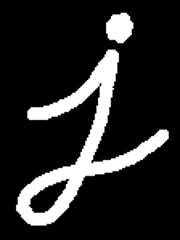

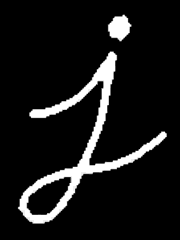

In [41]:
img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/j.png',0)
kernel = np.ones((5,5),np.uint8)
print(kernel)


#Erosao
erosion = cv2.erode(img,kernel,iterations = 1)
cv2_imshow(img)
cv2_imshow(erosion)

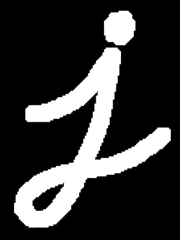

In [42]:
dilation = cv2.dilate(img,kernel,iterations = 1)
cv2_imshow(dilation)

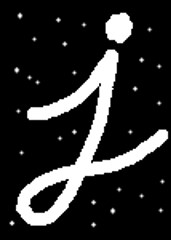

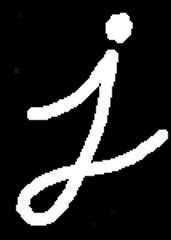

In [44]:
#Abertura (#erosao mais dilatacao)
img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/j_a.jpg',0)
opening = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
cv2_imshow(img)
cv2_imshow(opening)

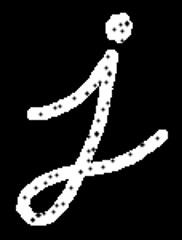

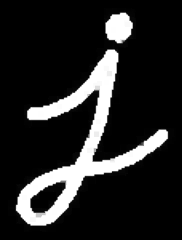

In [46]:
#Fechamento (dilatacao + erosao)
img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/j_f.jpg',0)
closing = cv2.morphologyEx(img, cv2.MORPH_CLOSE, kernel)
cv2_imshow(img)
cv2_imshow(closing)

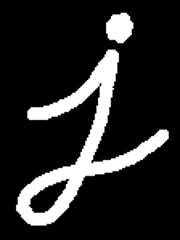

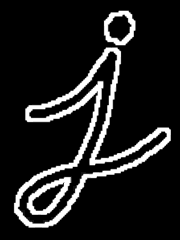

In [48]:
img = cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/j.png',0)
gradient = cv2.morphologyEx(img, cv2.MORPH_GRADIENT, kernel)
cv2_imshow(img)
cv2_imshow(gradient)

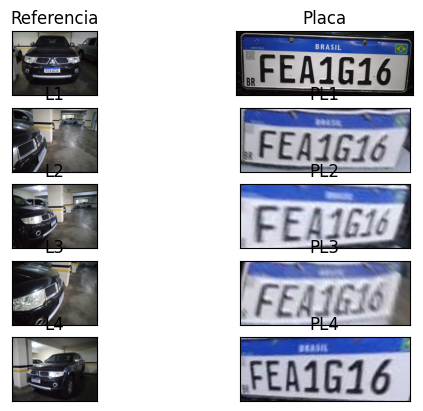

In [32]:
#Visualizando todas as placas
from matplotlib import pyplot as plt

titulos = ['Referencia','Placa','L1','PL1','L2','PL2','L3','PL3','L4','PL4']
CR= cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/placa_ampliada.jpg')
IR=cv2.imread('/content/drive/MyDrive/ELT578/SEMANA_2/placa_referencia.jpg')
imagens = [CR, IR, I1, IT1, I2, IT2, I3, IT3, I4, IT4]
for i in list(range(10)):
 plt.subplot (5,2,i+1), plt.imshow(cv2.cvtColor(imagens[i], cv2.COLOR_BGR2RGB))
 plt.title(titulos[i])
 plt.xticks([]), plt.yticks([])
plt.show()

**5) Métricas de Qualidade de Imagem**

* **Erro Quadrático Médio (MSE - Mean Squared Error):** Mede a média dos erros ao quadrado entre a imagem original (f) e a imagem comparada (g). Quanto menor o MSE, mais semelhantes são as imagens. Sensível a grandes diferenças, pois os erros são elevados ao quadrado.

* **Erro Máximo (ME - Maximum Error):** Representa a maior diferença absoluta entre os pixels das duas imagens. Indica o pior caso de erro. Útil para identificar outliers ou erros localizados.

* **Erro Médio Absoluto (MAE - Mean Absolute Error):** Mede a média das diferenças absolutas entre as imagens. Não penaliza tanto grandes diferenças como o MSE. Interpretação simples: quanto menor, melhor.

* **Raiz do Erro Quadrático Médio (RMSE - Root Mean Squared Error):** É a raiz quadrada do MSE. Mantém a unidade dos valores originais (diferente do MSE que é ao quadrado). Fácil de interpretar: quanto menor, mais próxima está a imagem processada da original.

* **Erro Médio Quadrático Normalizado (NMSE - Normalized Mean Squared Error):**
Normaliza o MSE em relação à energia da imagem original. Permite comparar erros entre imagens com diferentes níveis de intensidade ou contraste. Próximo de 0 indica alta similaridade.

* **Coeficiente de Correlação:** Mede a correlação linear entre as imagens. Considera variação global, não apenas diferenças ponto a ponto. Valores: +1 → correlação perfeita (idênticas, exceto escala); 0 → sem correlação; -1 → inversamente correlacionadas.

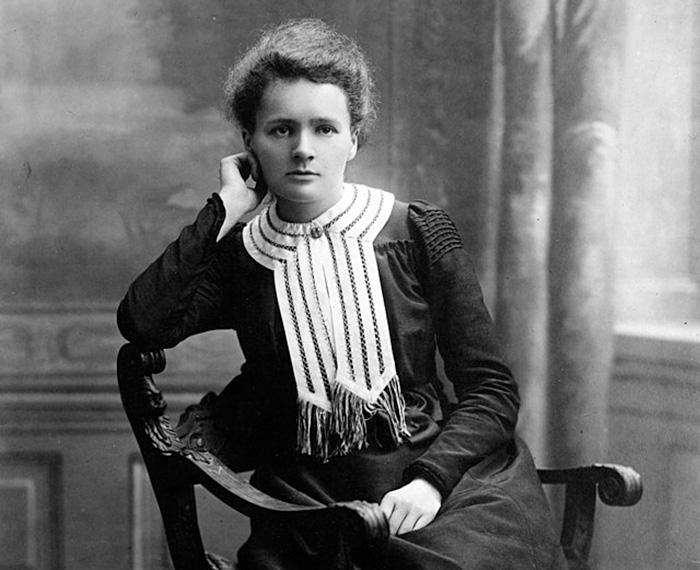

(570, 700, 3)


In [40]:
ie=cv2.imread("/content/drive/MyDrive/ELT578/SEMANA_2/marie_curie.jpg")
cv2_imshow(ie)
print(ie.shape)

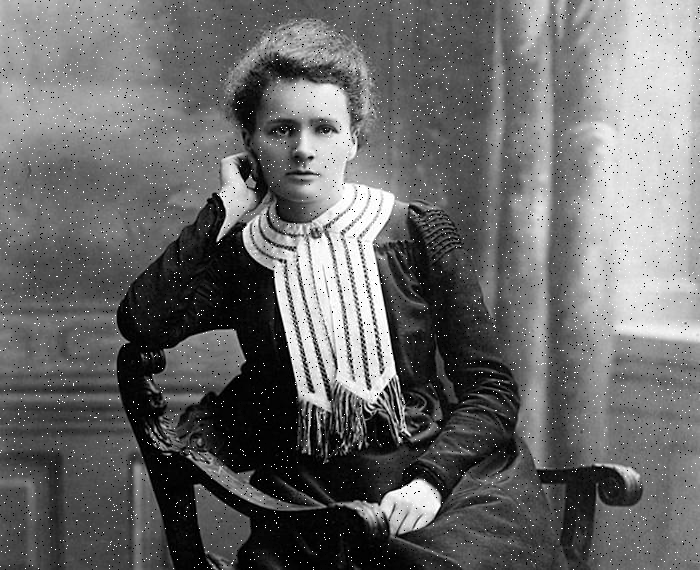

In [34]:
#Salt & Pepper (Chuvisco)
def add_chuvisco(original, controle):
    ruido = np.random.rand(original.shape[0], original.shape[1])
    ruidosa = original.copy()
    ruidosa[ruido < controle] = 0       # pontos pretos
    ruidosa[ruido > 1-controle] = 255   # pontos brancos
    return ruidosa

ie_noisy = add_chuvisco(ie, 0.01)
cv2_imshow(ie_noisy)

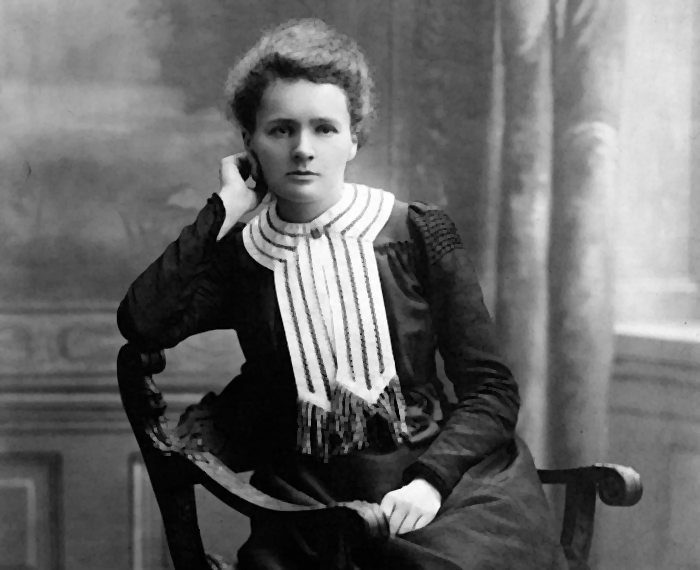

In [37]:
median_filtered = cv2.medianBlur(ie_noisy, 3)
kernel = np.ones((3, 3), np.uint8)
ie_p = cv2.morphologyEx(median_filtered, cv2.MORPH_OPEN, kernel)
cv2_imshow(ie_p)

In [38]:

def calc_metrics(f, g):
    # Erro Quadrático Médio
    MSE = np.sum(np.square(f.astype(float) - g.astype(float))) / (f.shape[0] * f.shape[1])

    # Erro Máximo
    ME = np.max(np.abs(f.astype(float) - g.astype(float)))

    # Erro Médio Absoluto
    MAE = np.sum(np.abs(f.astype(float) - g.astype(float))) / (f.shape[0] * f.shape[1])

    # Raiz do Erro Quadrático Médio
    RMSE = np.sqrt(MSE)

    # Erro Médio Quadrático Normalizado
    NMSE = MSE / np.sum(np.square(f.astype(float)))

    # Coeficiente de correlação
    Corr = np.corrcoef(f.flatten(), g.flatten())[0, 1]

    return {
        'MSE': MSE,
        'ME': ME,
        'MAE': MAE,
        'RMSE': RMSE,
        'NMSE': NMSE,
        'Correlation': Corr
    }

# Exemplo com imagens ie (original), ie_noisy e ie_p (processada)
metrics_noisy = calc_metrics(ie, ie_noisy)
metrics_processed = calc_metrics(ie, ie_p)

print("Métricas entre Original e Ruído:")
for k, v in metrics_noisy.items():
    print(f"{k}: {v:.4f}")

print("\nMétricas entre Original e Processada:")
for k, v in metrics_processed.items():
    print(f"{k}: {v:.4f}")

Métricas entre Original e Ruído:
MSE: 1242.7208
ME: 255.0000
MAE: 7.5174
RMSE: 35.2522
NMSE: 0.0000
Correlation: 0.9533

Métricas entre Original e Processada:
MSE: 191.9415
ME: 201.0000
MAE: 8.9828
RMSE: 13.8543
NMSE: 0.0000
Correlation: 0.9926


**5.1) SSIM – Structural Similarity Index**

* Mede a similaridade estrutural entre duas imagens, considerando luminância, contraste e estrutura. Baseado em similaridade perceptual (como o olho humano percebe). Varia entre -1 e 1, sendo:

* 1 → imagens idênticas.

* Próximo de 1 → muito similares.
* < 0.5 → diferentes estruturalmente.


In [39]:
from skimage.metrics import structural_similarity as ssim

# SSIM: mede a similaridade perceptual (considera luminância, contraste e estrutura)
# Varia entre -1 e 1: 1 = imagens idênticas, próximo de 1 = alta similaridade.

ssim_noisy = ssim(ie, ie_noisy, win_size=3, channel_axis=-1)
ssim_processed = ssim(ie, ie_p, win_size=3, channel_axis=-1)

print("\n### Métrica SSIM (Similaridade Estrutural) ###")
print(f"Original vs Ruído: SSIM = {ssim_noisy:.4f}")
print(f"Original vs Processada: SSIM = {ssim_processed:.4f}")



### Métrica SSIM (Similaridade Estrutural) ###
Original vs Ruído: SSIM = 0.8659
Original vs Processada: SSIM = 0.9018


**Desafio**
 * Detecção automática de pontos para transformaçao em perspectiva